In [133]:
import pandas as pd

In [134]:
df = pd.read_csv("Linear _1 assement.csv")

In [135]:
df.head()

,fish_id,species,length1_cm,length2_cm,length3_cm,height_cm,width_cm,girth_cm,age_years,water_temp_c,weight_g
0,1,Salmon,80.4,84.2,86.6,33.2,20.1,29.8,2.8,12.1,38281.6
1,2,Perch,21.3,22.1,22.6,7.6,7.1,8.5,3.5,8.7,802.8
2,3,Roach,16.1,16.8,17.5,5.9,4.3,5.5,1.3,10.6,225.9
3,4,Perch,12.2,12.7,13.0,4.4,3.7,5.0,1.3,16.1,155.2
4,5,Perch,32.8,33.6,35.2,13.6,10.2,14.2,4.8,21.8,3154.2


In [136]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 476 entries, 0 to 475
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   fish_id       476 non-null    int64  
 1   species       476 non-null    object 
 2   length1_cm    476 non-null    float64
 3   length2_cm    476 non-null    float64
 4   length3_cm    476 non-null    float64
 5   height_cm     476 non-null    float64
 6   width_cm      476 non-null    float64
 7   girth_cm      476 non-null    float64
 8   age_years     476 non-null    float64
 9   water_temp_c  476 non-null    float64
 10  weight_g      476 non-null    float64
dtypes: float64(9), int64(1), object(1)
memory usage: 41.0+ KB


In [137]:
df.shape

(476, 11)

In [138]:
df.dtypes

fish_id           int64
species          object
length1_cm      float64
length2_cm      float64
length3_cm      float64
height_cm       float64
width_cm        float64
girth_cm        float64
age_years       float64
water_temp_c    float64
weight_g        float64
dtype: object

In [139]:
df['species'].value_counts()

species
Roach        75
Salmon       74
Pike         71
Perch        67
Whitefish    67
Bream        61
Smelt        61
Name: count, dtype: int64

In [140]:
df.describe()

,fish_id,length1_cm,length2_cm,length3_cm,height_cm,width_cm,girth_cm,age_years,water_temp_c,weight_g
count,476.000000,476.000000,476.000000,476.000000,476.000000,476.000000,476.000000,476.000000,476.000000,476.000000
mean,238.500000,37.926471,39.464706,40.822269,14.157143,10.096218,14.485294,3.461975,15.020378,6086.735714
std,137.553626,20.010818,20.856469,21.521104,7.476152,5.200173,7.324341,1.573653,4.007118,8055.291401
min,1.000000,7.100000,7.300000,7.600000,1.800000,1.300000,2.100000,0.700000,8.000000,7.000000
25%,119.750000,21.400000,22.175000,23.100000,8.100000,6.100000,8.450000,2.200000,11.700000,716.125000
50%,238.500000,33.850000,35.250000,36.450000,13.600000,9.800000,14.150000,3.100000,14.950000,3231.950000
75%,357.250000,48.950000,51.125000,53.050000,18.725000,13.325000,20.100000,4.600000,18.400000,8056.200000
max,476.000000,89.700000,93.900000,96.400000,36.100000,25.600000,33.300000,7.600000,22.000000,48866.900000


In [141]:
df.isnull().sum()

fish_id         0
species         0
length1_cm      0
length2_cm      0
length3_cm      0
height_cm       0
width_cm        0
girth_cm        0
age_years       0
water_temp_c    0
weight_g        0
dtype: int64

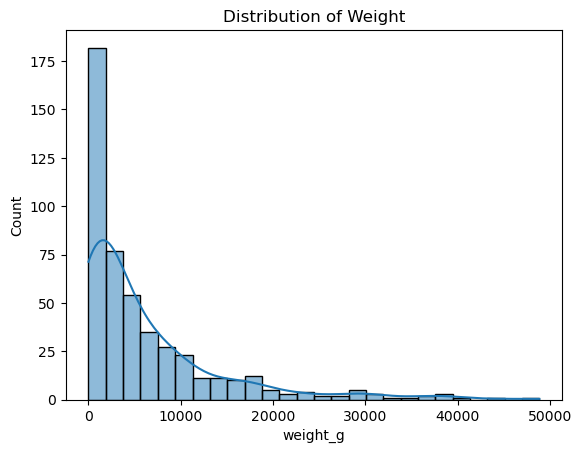

In [142]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.histplot(df['weight_g'], kde=True)
plt.title("Distribution of Weight")
plt.show()

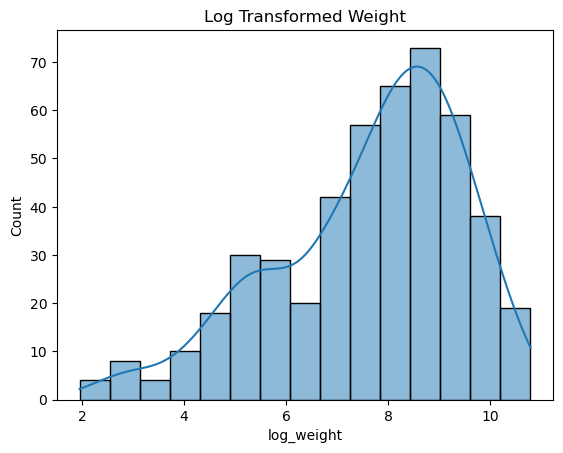

In [143]:
import numpy as np

df['log_weight'] = np.log(df['weight_g'])

sns.histplot(df['log_weight'], kde=True)
plt.title("Log Transformed Weight")
plt.show()

In [144]:
corr = df.corr(numeric_only=True)

weight_corr = corr['weight_g'].sort_values(ascending=False)

print(weight_corr)

weight_g        1.000000
height_cm       0.862560
girth_cm        0.853919
width_cm        0.848232
length2_cm      0.835024
length1_cm      0.834787
length3_cm      0.833804
log_weight      0.724513
age_years       0.266010
fish_id         0.029407
water_temp_c   -0.030459
Name: weight_g, dtype: float64


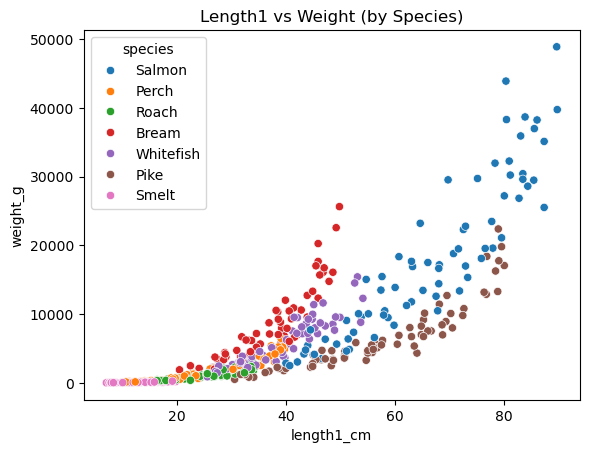

In [145]:
plt.figure()
sns.scatterplot(data=df, x='length1_cm', y='weight_g', hue='species')
plt.title("Length1 vs Weight (by Species)")
plt.show()

In [146]:
df['volume_proxy'] = df['length1_cm']*df['height_cm']*df['width_cm']

In [147]:
df['volume_proxy']

0      53652.528
1       1149.348
2        408.457
3        198.616
4       4550.016
         ...    
471      204.600
472    15860.320
473      468.480
474      627.750
475    63949.600
Name: volume_proxy, Length: 476, dtype: float64

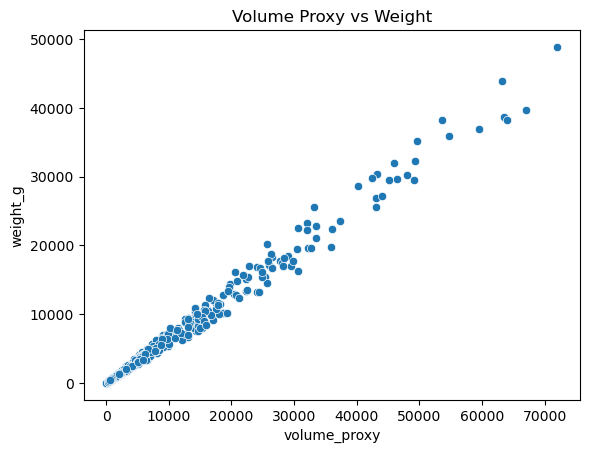

In [148]:
plt.figure()
sns.scatterplot(x=df['volume_proxy'], y=df['weight_g'])
plt.title("Volume Proxy vs Weight")
plt.show()

In [149]:
df['log_volume'] = np.log(df['volume_proxy'])

# Correlation
print(df[['log_weight', 'log_volume']].corr())

            log_weight  log_volume
log_weight    1.000000    0.998028
log_volume    0.998028    1.000000


In [150]:
df['length_sq'] = df['length1_cm'] ** 2
df['length_cu'] = df['length1_cm'] ** 3

In [151]:
df['length_x_girth'] = df['length1_cm'] * df['girth_cm']

In [152]:
df.drop(['fish_id'],axis=1,inplace=True)

In [153]:
df = pd.get_dummies(df, columns=['species'], drop_first=True)
df

,length1_cm,length2_cm,length3_cm,height_cm,width_cm,girth_cm,age_years,water_temp_c,weight_g,log_weight,...,log_volume,length_sq,length_cu,length_x_girth,species_Perch,species_Pike,species_Roach,species_Salmon,species_Smelt,species_Whitefish
0,80.4,84.2,86.6,33.2,20.1,29.8,2.8,12.1,38281.6,10.552725,...,10.890284,6464.16,519718.464,2395.92,False,False,False,True,False,False
1,21.3,22.1,22.6,7.6,7.1,8.5,3.5,8.7,802.8,6.688106,...,7.046950,453.69,9663.597,181.05,True,False,False,False,False,False
2,16.1,16.8,17.5,5.9,4.3,5.5,1.3,10.6,225.9,5.420092,...,6.012387,259.21,4173.281,88.55,False,False,True,False,False,False
3,12.2,12.7,13.0,4.4,3.7,5.0,1.3,16.1,155.2,5.044715,...,5.291373,148.84,1815.848,61.00,True,False,False,False,False,False
4,32.8,33.6,35.2,13.6,10.2,14.2,4.8,21.8,3154.2,8.056490,...,8.422886,1075.84,35287.552,465.76,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
471,12.4,12.9,13.3,5.0,3.3,5.3,1.3,9.6,138.1,4.927978,...,5.321057,153.76,1906.624,65.72,True,False,False,False,False,False
472,68.6,72.0,74.2,17.0,13.6,17.1,5.7,14.5,8432.8,9.039884,...,9.671576,4705.96,322828.856,1173.06,False,True,False,False,False,False
473,19.2,19.6,20.5,6.1,4.0,5.7,7.2,11.8,248.1,5.513832,...,6.149493,368.64,7077.888,109.44,False,False,False,False,True,False
474,22.5,23.8,24.6,6.2,4.5,8.0,3.6,8.1,372.4,5.919969,...,6.442142,506.25,11390.625,180.00,False,False,True,False,False,False


In [154]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error

x = df.drop(columns=['weight_g', 'log_weight'])  # exclude target
y = df['weight_g']

In [155]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [156]:
model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

In [157]:
r2 = r2_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("R2_score:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

R2_score: 0.9916265275641092
RMSE: 731.3088554883011
MAE: 415.0282351060371


In [158]:
x = df.drop(columns=['weight_g', 'log_weight'])
y_log = df['log_weight']

In [159]:

x_train, x_test, y_train, y_test = train_test_split(x, y_log, test_size=0.2, random_state=42)

In [160]:
model_log = LinearRegression()
model_log.fit(x_train, y_train)
y_pred_log = model_log.predict(x_test) 

y_pred2 = np.exp(y_pred_log)
y_true = np.exp(y_test)

r2_log = r2_score(y_true, y_pred2)
mae2 = mean_absolute_error(y_true, y_pred2)
mse2 = mean_squared_error(y_true, y_pred2)
rmse2 = np.sqrt(mse2)

print("R2_score (log model):", r2_log)
print("MAE (log model):", mae2)
print("MSE (log model):", mse2)
print("RMSE (log model):", rmse2)

R2_score (log model): 0.9951099446005448
MAE (log model): 314.98291939496374
MSE (log model): 312327.2296287316
RMSE (log model): 558.8624424925437


In [161]:
# Metrics table
metrics = pd.DataFrame({
    "Model": ["Linear", "Log-weight"],
    "RMSE": [rmse, rmse2],
    "MAE": [mae, mae2],
    "R2": [r2, r2_log]
})
print(metrics)

        Model        RMSE         MAE        R2
0      Linear  731.308855  415.028235  0.991627
1  Log-weight  558.862442  314.982919  0.995110


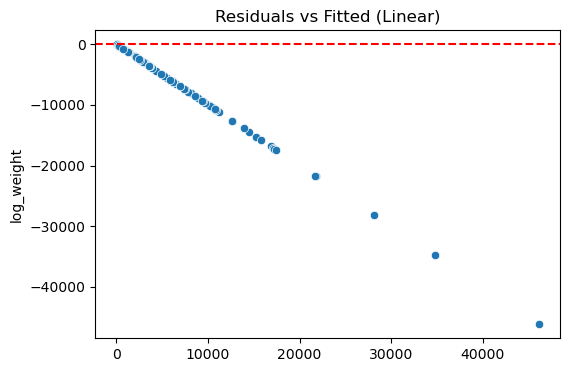

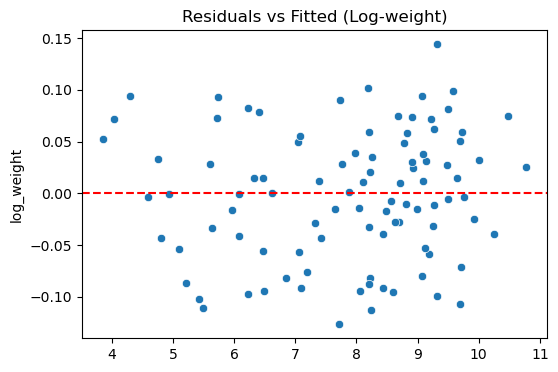

In [162]:
# Residual plots
plt.figure(figsize=(6,4))
sns.scatterplot(x=y_pred, y=y_test - y_pred)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs Fitted (Linear)")
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(x=y_pred_log, y=y_test - y_pred_log)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs Fitted (Log-weight)")
plt.show()

In [163]:
import joblib

joblib.dump(model, "model.pkl")

['model.pkl']

In [164]:
# Save feature column names
feature_cols = x.columns.tolist()
joblib.dump(feature_cols, open("model_columns.pkl", "wb"))

In [165]:
print(x.columns.tolist())

['length1_cm', 'length2_cm', 'length3_cm', 'height_cm', 'width_cm', 'girth_cm', 'age_years', 'water_temp_c', 'volume_proxy', 'log_volume', 'length_sq', 'length_cu', 'length_x_girth', 'species_Perch', 'species_Pike', 'species_Roach', 'species_Salmon', 'species_Smelt', 'species_Whitefish']
